# Глава 3

## 3.1 Импорт библиотек и БД

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

df_mono_known = pd.read_excel('../data/df_mono_known.xlsx')
df_nomono_known = pd.read_excel('../data/df_nomono_known.xlsx')
df_all = pd.read_excel('../data/df_all.xlsx')

## 3.2 Mathcing

In [17]:
def extract_severity(ther):
    if 'среднетяжелое' in ther:
        return 'среднетяжёлое'
    else:
        return 'тяжёлое'#тяжелое и крайне тяжелое 

df_all['Severity'] = df_all['Ther'].apply(extract_severity)

print(df_all['Severity'].value_counts())

Severity
среднетяжёлое    7094
тяжёлое          2487
Name: count, dtype: int64


In [3]:
df_mono_s = df_all[(df_all['group'] == 'МОНО') & 
                      df_all['Результат_D_чистый'].notna() & df_all['Результат_F_чистый'].notna()].reset_index(drop=True)

df_nomono_s = df_all[(df_all['group'] == 'БЕЗ МОНО') & 
                      df_all['Результат_D_чистый'].notna() & df_all['Результат_F_чистый'].notna()].reset_index(drop=True)

print(f"МОНО для матчинга: {len(df_mono_s)}")
print(f"БЕЗ МОНО для матчинга: {len(df_nomono_s)}")

МОНО для матчинга: 2384
БЕЗ МОНО для матчинга: 5301


In [20]:
matched_mono = []
matched_nomono = []
used_nomono = set()

# сортируем сначала редкие пациенты (крайние значения)
df_mono_s = df_mono_s.sort_values(
    ['Severity', 'Age', 'Результат_D_чистый', 'Результат_F_чистый'],
    ascending=[True, False, False, False]
).reset_index(drop=True)

no_match_at_all = []   # не было подходящего в БЕЗ МОНО вообще
no_match_taken  = []   # подходящие были, но все заняты

for idx, patient in df_mono_s.iterrows():
    # Все подходящие без учёта занятости
    all_match = df_nomono_s[
        (df_nomono_s['Gender'] == patient['Gender']) &
        (df_nomono_s['Severity'] == patient['Severity']) &
        (df_nomono_s['Age'].between(patient['Age'] - 3, patient['Age'] + 3)) &
        (df_nomono_s['Результат_D_чистый'].between(patient['Результат_D_чистый'] * 0.9,
            patient['Результат_D_чистый'] * 1.1)) &
        (df_nomono_s['Результат_F_чистый'].between(patient['Результат_F_чистый'] * 0.9,
            patient['Результат_F_чистый'] * 1.1))
    ]

    # свободные из подходящих
    free_match = all_match[~all_match.index.isin(used_nomono)]

    if len(free_match) > 0:
        chosen = free_match.iloc[0]
        matched_mono.append(patient)
        matched_nomono.append(chosen)
        used_nomono.add(chosen.name)
    elif len(all_match) == 0:
        no_match_at_all.append(patient['CaseID'])
    else:
        no_match_taken.append(patient['CaseID'])

df_matched_mono   = pd.DataFrame(matched_mono).reset_index(drop=True)
df_matched_nomono = pd.DataFrame(matched_nomono).reset_index(drop=True)

print(f"Подобрано пар:                        {len(df_matched_mono)}")
print(f"Покрытие МОНО:                        {len(df_matched_mono) / len(df_mono_s) * 100:.1f}%")
print(f"Не нашли пару (нет подходящих):       {len(no_match_at_all)}")
print(f"Не нашли пару (все подходящие заняты): {len(no_match_taken)}")

Подобрано пар:                        1020
Покрытие МОНО:                        42.8%
Не нашли пару (нет подходящих):       1224
Не нашли пару (все подходящие заняты): 140


In [21]:
from scipy import stats

#возраст
t, p = stats.ttest_ind(df_matched_mono['Age'], df_matched_nomono['Age'])
print(f"Возраст: t={t:.3f}, p={p:.3f}")

# показатель D
t, p = stats.ttest_ind(df_matched_mono['Результат_D_чистый'], df_matched_nomono['Результат_D_чистый'])
print(f"Показатель D: t={t:.3f}, p={p:.3f}")

#показатель F
t, p = stats.ttest_ind(df_matched_mono['Результат_F_чистый'], df_matched_nomono['Результат_F_чистый'])
print(f"Показатель F: t={t:.3f}, p={p:.3f}")

#пол
ct = pd.crosstab(
    pd.concat([df_matched_mono['Gender'], df_matched_nomono['Gender']], ignore_index=True),
    pd.concat([pd.Series(['МОНО']*len(df_matched_mono)),
               pd.Series(['БЕЗ МОНО']*len(df_matched_nomono))], ignore_index=True)
)
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"Пол: chi2={chi2:.3f}, p={p:.3f}")

# тяжесть
ct = pd.crosstab(
    pd.concat([df_matched_mono['Severity'], df_matched_nomono['Severity']], ignore_index=True),
    pd.concat([pd.Series(['МОНО']*len(df_matched_mono)),
               pd.Series(['БЕЗ МОНО']*len(df_matched_nomono))], ignore_index=True)
)
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"Тяжесть: chi2={chi2:.3f}, p={p:.3f}")

Возраст: t=0.462, p=0.644
Показатель D: t=0.144, p=0.886
Показатель F: t=0.164, p=0.870
Пол: chi2=0.000, p=1.000
Тяжесть: chi2=0.000, p=1.000


Обе группы полностью сопоставимы по всем факторам, p-value (уровень значимости) > 0.05, а значит мы не можем отвергнуть нулевую гипотезу об отсутствии различий

## 3.3 Сравнение групп по исходам

In [22]:
ct = pd.crosstab(
    pd.concat([df_matched_mono['Outcome'], df_matched_nomono['Outcome']], ignore_index=True),
    pd.concat([pd.Series(['МОНО']*len(df_matched_mono)),
               pd.Series(['БЕЗ МОНО']*len(df_matched_nomono))], ignore_index=True)
)
chi2, p, _, _ = stats.chi2_contingency(ct)
print(ct)
print(f"\nchi2={chi2:.3f}, p={p:.3f}")
print(f"\nМОНО: умерло {df_matched_mono['dead'].sum()} из {len(df_matched_mono)} ({df_matched_mono['dead'].mean()*100:.1f}%)")
print(f"БЕЗ МОНО: умерло {df_matched_nomono['dead'].sum()} из {len(df_matched_nomono)} ({df_matched_nomono['dead'].mean()*100:.1f}%)")

col_0    БЕЗ МОНО  МОНО
Outcome                
Выписан       837   863
Умер          183   157

chi2=2.206, p=0.137

МОНО: умерло 157 из 1020 (15.4%)
БЕЗ МОНО: умерло 183 из 1020 (17.9%)


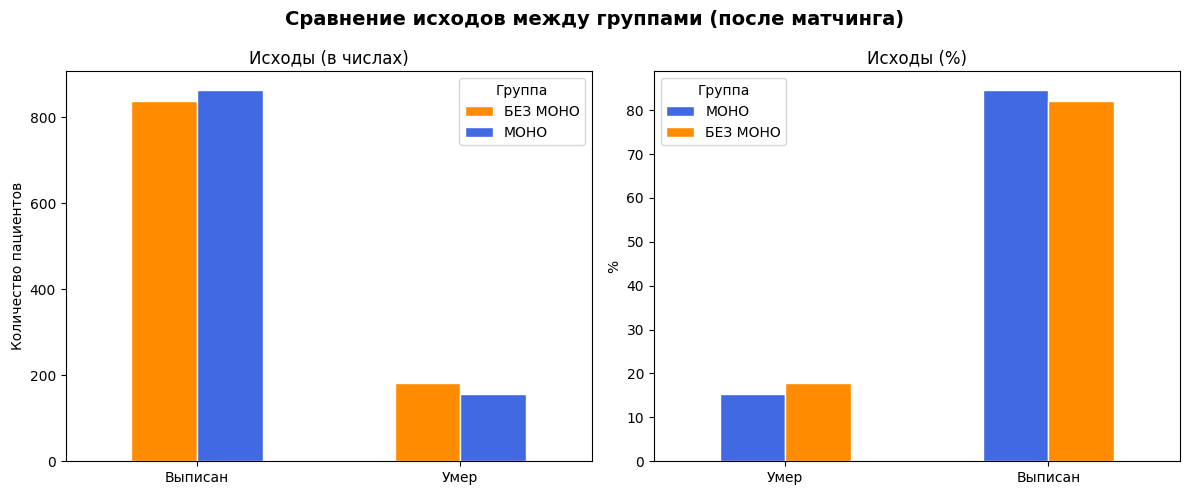

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Сравнение исходов между группами (после матчинга)', fontsize=14, fontweight='bold')

# 1. Абсолютные числа
ct.plot(kind='bar', ax=axes[0], color=['darkorange', 'royalblue'], edgecolor='white')
axes[0].set_title('Исходы (в числах)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Количество пациентов')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Группа')

# 2. Проценты
pct_data = pd.DataFrame({
    'МОНО':     [df_matched_mono['dead'].mean()*100, (1-df_matched_mono['dead'].mean())*100],
    'БЕЗ МОНО': [df_matched_nomono['dead'].mean()*100, (1-df_matched_nomono['dead'].mean())*100]
}, index=['Умер', 'Выписан'])

pct_data.plot(kind='bar', ax=axes[1], color=['royalblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Исходы (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Группа')

plt.tight_layout()
plt.show()

Летальность в группе МОНО составила 14.7% против 17.6% в группе БЕЗ МОНО. Несмотря на то что в группе с препаратом умерло меньше пациентов, эта разница статистически незначима (p=0.137). Т.е. по данным этого исследования нельзя однозначно утверждать что препарат снижает смертность, но тенденция в пользу лечения есть

## 3.4 Сроки госпитализации у выживших

In [27]:
#длительность госпитализации
df_matched_mono['Start'] = pd.to_datetime(df_matched_mono['Start'])
df_matched_mono['End']   = pd.to_datetime(df_matched_mono['End'])
df_matched_nomono['Start'] = pd.to_datetime(df_matched_nomono['Start'])
df_matched_nomono['End']   = pd.to_datetime(df_matched_nomono['End'])

df_matched_mono['duration']   = (df_matched_mono['End'] - df_matched_mono['Start']).dt.days
df_matched_nomono['duration'] = (df_matched_nomono['End'] - df_matched_nomono['Start']).dt.days

#только выжившие
alive_mono   = df_matched_mono[df_matched_mono['dead'] == 0]['duration'].dropna()
alive_nomono = df_matched_nomono[df_matched_nomono['dead'] == 0]['duration'].dropna()

print(f"МОНО — выжившие: n={len(alive_mono)}, медиана={alive_mono.median():.1f} дней, среднее={alive_mono.mean():.1f} ± {alive_mono.std():.1f}")
print(f"БЕЗ МОНО — выжившие: n={len(alive_nomono)}, медиана={alive_nomono.median():.1f} дней, среднее={alive_nomono.mean():.1f} ± {alive_nomono.std():.1f}")

# статистический тест
stat, p = stats.mannwhitneyu(alive_mono, alive_nomono, alternative='two-sided')
print(f"\nМанна–Уитни: U={stat:.1f}, p={p:.3f}")
if p < 0.05:
    print("Различие статистически значимо: группы выздоравливали с разной скоростью.")
else:
    print("Различие статистически незначимо: скорость выздоровления в группах сопоставима.")

МОНО — выжившие: n=863, медиана=14.0 дней, среднее=15.1 ± 8.0
БЕЗ МОНО — выжившие: n=837, медиана=10.0 дней, среднее=11.6 ± 6.9

Манна–Уитни: U=483454.5, p=0.000
Различие статистически значимо: группы выздоравливали с разной скоростью.


C:\Users\User\AppData\Local\Temp\ipykernel_8328\3777354637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dur_df, x='Группа', y='Дней',


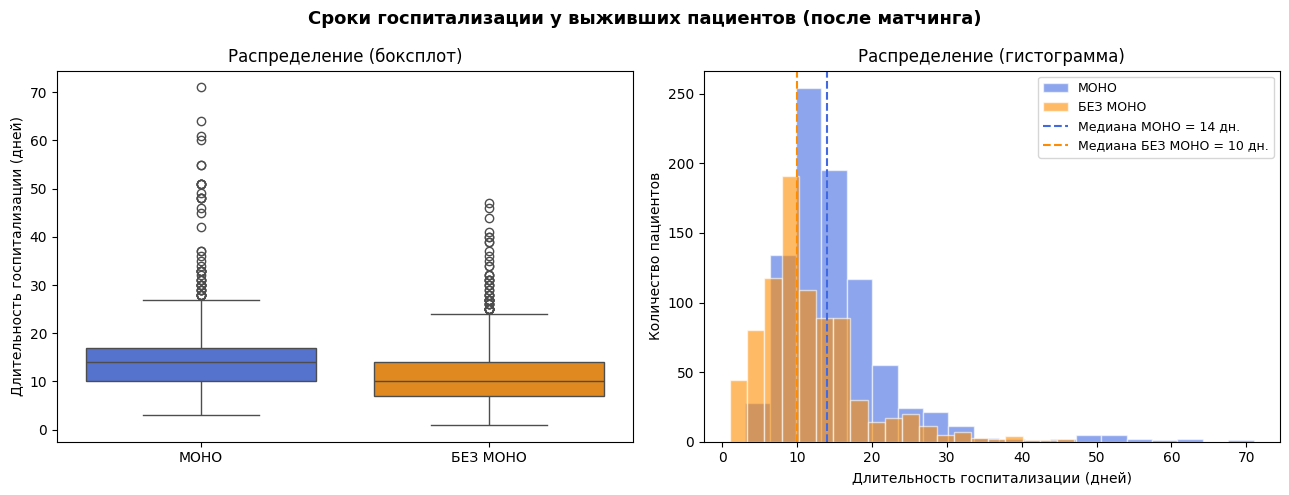

In [28]:
# визуализация сроков госпитализации у выживших
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Сроки госпитализации у выживших пациентов (после матчинга)', fontsize=13, fontweight='bold')

dur_df = pd.DataFrame({
    'Дней': pd.concat([alive_mono, alive_nomono], ignore_index=True),
    'Группа': ['МОНО'] * len(alive_mono) + ['БЕЗ МОНО'] * len(alive_nomono)
})
sns.boxplot(data=dur_df, x='Группа', y='Дней',
            palette={'МОНО': 'royalblue', 'БЕЗ МОНО': 'darkorange'}, ax=axes[0])
axes[0].set_title('Распределение (боксплот)')
axes[0].set_ylabel('Длительность госпитализации (дней)')
axes[0].set_xlabel('')

# Гистограммы
axes[1].hist(alive_mono,   bins=20, alpha=0.6, color='royalblue',  label='МОНО',     edgecolor='white')
axes[1].hist(alive_nomono, bins=20, alpha=0.6, color='darkorange', label='БЕЗ МОНО', edgecolor='white')
axes[1].axvline(alive_mono.median(),   color='royalblue',  linestyle='--', linewidth=1.5, label=f'Медиана МОНО = {alive_mono.median():.0f} дн.')
axes[1].axvline(alive_nomono.median(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Медиана БЕЗ МОНО = {alive_nomono.median():.0f} дн.')
axes[1].set_title('Распределение (гистограмма)')
axes[1].set_xlabel('Длительность госпитализации (дней)')
axes[1].set_ylabel('Количество пациентов')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3.5 Влияние отдельных факторов на исходы

In [29]:
df_matched = pd.concat([df_matched_mono, df_matched_nomono], ignore_index=True)

In [31]:
# бинарная вакцинация
df_matched['Vaccinated'] = 'Не привит'
df_matched.loc[df_matched['Vacin'].notna() & (df_matched['Vacin'] != 'Нет'), 'Vaccinated'] = 'Привит'

# возраст умершие vs выжившие
age_dead  = df_matched[df_matched['dead'] == 1]['Age']
age_alive = df_matched[df_matched['dead'] == 0]['Age']
stat, p = stats.mannwhitneyu(age_dead, age_alive, alternative='two-sided')
print(f"Возраст: U={stat:.1f}, p={p:.3f}")

# показатель D
d_dead  = df_matched[df_matched['dead'] == 1]['Результат_D_чистый']
d_alive = df_matched[df_matched['dead'] == 0]['Результат_D_чистый']
stat, p = stats.mannwhitneyu(d_dead, d_alive, alternative='two-sided')
print(f"Показатель D: U={stat:.1f}, p={p:.3f}")

# показатель F
f_dead  = df_matched[df_matched['dead'] == 1]['Результат_F_чистый']
f_alive = df_matched[df_matched['dead'] == 0]['Результат_F_чистый']
stat, p = stats.mannwhitneyu(f_dead, f_alive, alternative='two-sided')
print(f"Показатель F: U={stat:.1f}, p={p:.3f}")

# пол
ct = pd.crosstab(df_matched['Gender'], df_matched['dead'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"Пол: chi2={chi2:.3f}, p={p:.3f}")

# тяжесть
ct = pd.crosstab(df_matched['Severity'], df_matched['dead'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"Тяжесть: chi2={chi2:.3f}, p={p:.3f}")

# вакцинация
ct = pd.crosstab(df_matched['Vaccinated'], df_matched['dead'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"Вакцинация: chi2={chi2:.3f}, p={p:.3f}")

Возраст: U=425459.0, p=0.000
Показатель D: U=398942.0, p=0.000
Показатель F: U=389236.5, p=0.000
Пол: chi2=2.645, p=0.104
Тяжесть: chi2=890.825, p=0.000
Вакцинация: chi2=2.329, p=0.127


Значимыми факторами смерти оказались возраст, показатели D и F, а также тяжесть заболевания — по всем четырём p=0.000, то есть умершие пациенты были старше, имели более высокие маркеры воспаления и тромбообразования, и чаще относились к тяжёлой группе. Пол и статус вакцинации на исход значимо не повлияли — p=0.104 и p=0.127 соответственно, что вероятно связано с несбалансированностью вакцинированных между группами, а не с реальным отсутствием эффекта вакцинации

Значимые факторы риска смерти: возраст, тяжесть заболевания, показатели D и F. Пол и вакцинация на исход в этой выборке не влияют

C:\Users\User\AppData\Local\Temp\ipykernel_8328\548332708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_matched, x='dead', y='Age',
C:\Users\User\AppData\Local\Temp\ipykernel_8328\548332708.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Выписан', 'Умер'])
C:\Users\User\AppData\Local\Temp\ipykernel_8328\548332708.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_matched, x='dead', y='Результат_D_чистый',
C:\Users\User\AppData\Local\Temp\ipykernel_8328\548332708.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e

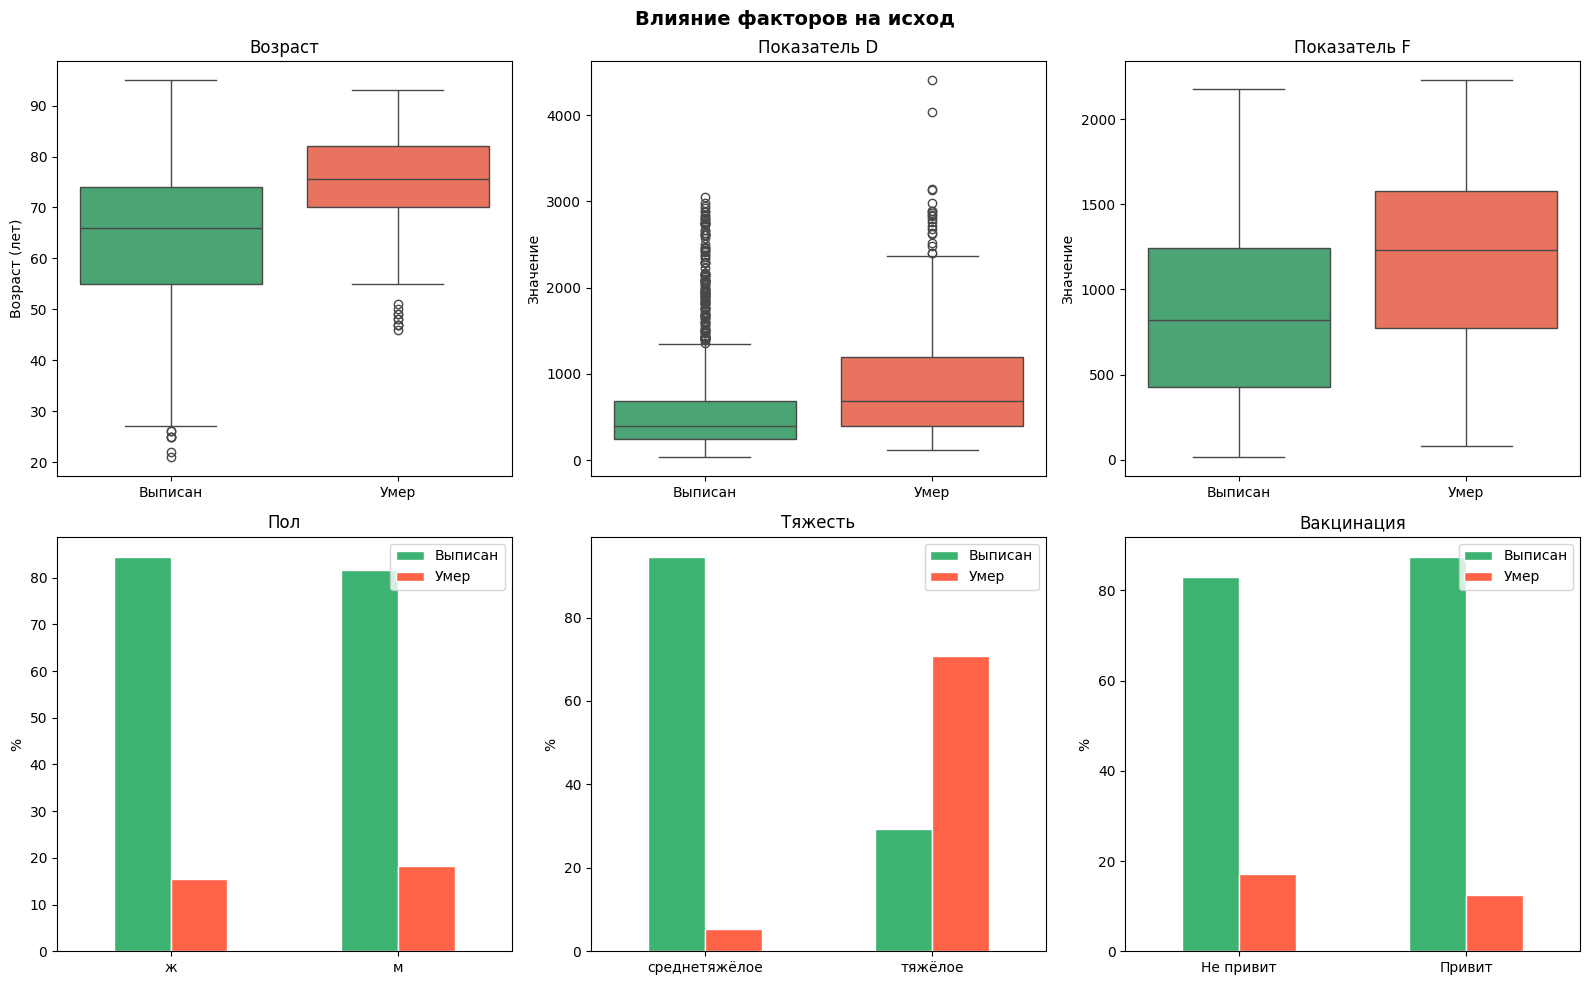

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Влияние факторов на исход', fontsize=14, fontweight='bold')

sns.boxplot(data=df_matched, x='dead', y='Age',
            palette=['mediumseagreen', 'tomato'], ax=axes[0, 0])
axes[0, 0].set_title('Возраст')
axes[0, 0].set_xlabel('')
axes[0, 0].set_xticklabels(['Выписан', 'Умер'])
axes[0, 0].set_ylabel('Возраст (лет)')

sns.boxplot(data=df_matched, x='dead', y='Результат_D_чистый',
            palette=['mediumseagreen', 'tomato'], ax=axes[0, 1])
axes[0, 1].set_title('Показатель D')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xticklabels(['Выписан', 'Умер'])
axes[0, 1].set_ylabel('Значение')

sns.boxplot(data=df_matched, x='dead', y='Результат_F_чистый',
            palette=['mediumseagreen', 'tomato'], ax=axes[0, 2])
axes[0, 2].set_title('Показатель F')
axes[0, 2].set_xlabel('')
axes[0, 2].set_xticklabels(['Выписан', 'Умер'])
axes[0, 2].set_ylabel('Значение')

gender_outcome = pd.crosstab(df_matched['Gender'], df_matched['dead'], normalize='index') * 100
gender_outcome.columns = ['Выписан', 'Умер']
gender_outcome.plot(kind='bar', color=['mediumseagreen', 'tomato'],
                    edgecolor='white', ax=axes[1, 0])
axes[1, 0].set_title('Пол')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('%')
axes[1, 0].tick_params(axis='x', rotation=0)

sev_outcome = pd.crosstab(df_matched['Severity'], df_matched['dead'], normalize='index') * 100
sev_outcome.columns = ['Выписан', 'Умер']
sev_outcome.plot(kind='bar', color=['mediumseagreen', 'tomato'],
                 edgecolor='white', ax=axes[1, 1])
axes[1, 1].set_title('Тяжесть')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('%')
axes[1, 1].tick_params(axis='x', rotation=0)

vac_outcome = pd.crosstab(df_matched['Vaccinated'], df_matched['dead'], normalize='index') * 100
vac_outcome.columns = ['Выписан', 'Умер']
vac_outcome.plot(kind='bar', color=['mediumseagreen', 'tomato'],
                 edgecolor='white', ax=axes[1, 2])
axes[1, 2].set_title('Вакцинация')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('%')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3.6 Matching с вакцинацией

In [13]:

df_mono_sv = df_mono_s.copy()
df_nomono_sv = df_nomono_s.copy()

df_mono_sv['Vaccinated'] = 'Не привит'
df_mono_sv.loc[df_mono_sv['Vacin'].notna() & (df_mono_sv['Vacin'] != 'Нет'), 'Vaccinated'] = 'Привит'

df_nomono_sv['Vaccinated'] = 'Не привит'
df_nomono_sv.loc[df_nomono_sv['Vacin'].notna() & (df_nomono_sv['Vacin'] != 'Нет'), 'Vaccinated'] = 'Привит'

print("Статус вакцинации МОНО:")
print(df_mono_sv['Vaccinated'].value_counts())
print("\nСтатус вакцинации БЕЗ МОНО:")
print(df_nomono_sv['Vaccinated'].value_counts())

Статус вакцинации МОНО:
Vaccinated
Не привит    1913
Привит        471
Name: count, dtype: int64

Статус вакцинации БЕЗ МОНО:
Vaccinated
Не привит    5301
Name: count, dtype: int64


In [14]:

matched_mono_v   = []
matched_nomono_v = []
used_nomono_v    = set()

for idx, patient in df_mono_sv.iterrows():
    match = df_nomono_sv[
        (df_nomono_sv['Gender']     == patient['Gender'])     &
        (df_nomono_sv['Severity']   == patient['Severity'])   &
        (df_nomono_sv['Vaccinated'] == patient['Vaccinated']) &
        (df_nomono_sv['Age'].between(patient['Age'] - 3, patient['Age'] + 3)) &
        (df_nomono_sv['Результат_D_чистый'].between(patient['Результат_D_чистый'] * 0.9,
                                                     patient['Результат_D_чистый'] * 1.1)) &
        (df_nomono_sv['Результат_F_чистый'].between(patient['Результат_F_чистый'] * 0.9,
                                                     patient['Результат_F_чистый'] * 1.1)) &
        (~df_nomono_sv.index.isin(used_nomono_v))
    ]
    if len(match) > 0:
        chosen = match.iloc[0]
        matched_mono_v.append(patient)
        matched_nomono_v.append(chosen)
        used_nomono_v.add(chosen.name)

df_matched_mono_v   = pd.DataFrame(matched_mono_v).reset_index(drop=True)
df_matched_nomono_v = pd.DataFrame(matched_nomono_v).reset_index(drop=True)

n_base = len(df_matched_mono)       # из матчинга без вакцинации
n_vacc = len(df_matched_mono_v)

print(f"Без критерия вакцинации: {n_base} пар")
print(f"С критерием вакцинации:  {n_vacc} пар")
print(f"Потеря пар: {n_base - n_vacc} ({(n_base - n_vacc) / n_base * 100:.1f}%)")

Без критерия вакцинации: 1020 пар
С критерием вакцинации:  843 пар
Потеря пар: 177 (17.4%)


МОНО (с вакцинацией): летальность 15.7%
БЕЗ МОНО (с вакцинацией): летальность 18.4%

chi2=2.032, p=0.154


C:\Users\User\AppData\Local\Temp\ipykernel_8328\840268868.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Матчинг', y='Пар',


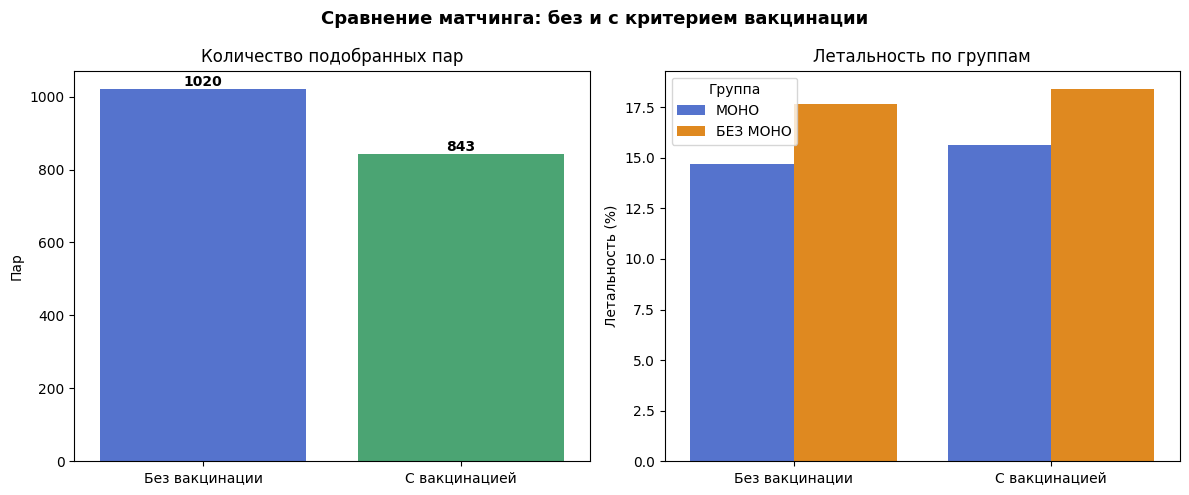

In [15]:
print(f"МОНО (с вакцинацией): летальность {df_matched_mono_v['dead'].mean()*100:.1f}%")
print(f"БЕЗ МОНО (с вакцинацией): летальность {df_matched_nomono_v['dead'].mean()*100:.1f}%")

ct_v = pd.crosstab(
    pd.concat([df_matched_mono_v['Outcome'], df_matched_nomono_v['Outcome']], ignore_index=True),
    pd.concat([pd.Series(['МОНО']*len(df_matched_mono_v)),
               pd.Series(['БЕЗ МОНО']*len(df_matched_nomono_v))], ignore_index=True)
)
chi2_v, p_v, _, _ = stats.chi2_contingency(ct_v)
print(f"\nchi2={chi2_v:.3f}, p={p_v:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Сравнение матчинга: без и с критерием вакцинации', fontsize=13, fontweight='bold')

summary = pd.DataFrame({
    'Матчинг': ['Без вакцинации', 'С вакцинацией'],
    'Пар': [n_base, n_vacc]
})
sns.barplot(data=summary, x='Матчинг', y='Пар',
            palette=['royalblue', 'mediumseagreen'], ax=axes[0])
axes[0].set_title('Количество подобранных пар')
axes[0].set_ylabel('Пар')
axes[0].set_xlabel('')
for bar, val in zip(axes[0].patches, summary['Пар']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontweight='bold')

leth = pd.DataFrame({
    'Группа': ['МОНО', 'БЕЗ МОНО', 'МОНО', 'БЕЗ МОНО'],
    'Матчинг': ['Без вакцинации']*2 + ['С вакцинацией']*2,
    'Летальность (%)': [
        df_matched_mono['dead'].mean()*100,
        df_matched_nomono['dead'].mean()*100,
        df_matched_mono_v['dead'].mean()*100,
        df_matched_nomono_v['dead'].mean()*100
    ]
})
sns.barplot(data=leth, x='Матчинг', y='Летальность (%)', hue='Группа',
            palette={'МОНО': 'royalblue', 'БЕЗ МОНО': 'darkorange'}, ax=axes[1])
axes[1].set_title('Летальность по группам')
axes[1].set_ylabel('Летальность (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

При добавлении критерия одинакового статуса вакцинации количество подобранных пар сократилось с 1020 до 843 (на 17.4%). Это объясняется тем, что в группе БЕЗ МОНО привитых пациентов не оказалось вовсе, поэтому матчинг фактически проводился только среди непривитых. Картина летальности при этом принципиально не изменилась: в группе МОНО она остаётся ниже, чем в группе БЕЗ МОНО